**Part 1: Hardware-Aware MLP Search:** We will first run a search on a single, well-defined architecture type (MLP). This allows us to use accurate, model-based hardware performance estimators (`rule4ml`) and visualize the complex trade-offs between accuracy, BOPs, and hardware resources.


In [ ]:

import os
import yaml
import tensorflow as tf
import pandas as pd

# Import the necessary search functions and visualization tools from the library
# Note: We import from two different modules to showcase both search types
from utils.tf_global_search import run_mlp_search
from utils.tf_global_search5 import GlobalSearchTF
from utils.tf_visualization import plot_pareto_fronts, plot_3d_pareto_front_heatmap

# Use matplotlib for inline plotting in notebooks
%matplotlib inline

# Suppress TensorFlow logging for cleaner output
tf.get_logger().setLevel('ERROR')

2025-08-30 08:18:31.312499: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ## Part 1: MLP-Only Hardware-Aware Search
#
# In this section, we'll perform a search over standard MLP architectures. Because the structure is well-defined, we can use hardware-aware estimators to get realistic performance metrics for FPGAs. This allows for a 4-objective optimization.

# %%
# --- Configuration for Part 1 ---
N_TRIALS_MLP = 5
EPOCHS_MLP = 10
SUBSET_SIZE_MLP = 10000
RESULTS_DIR_MLP = "./results/tutorial4_MLP"
USE_HARDWARE_METRICS = True # Enable hardware-aware metrics

# --- Objectives for Hardware-Aware Search ---
OBJECTIVE_NAMES_HW = ['accuracy', 'bops', 'avg_resource', 'clock_cycles']
MAXIMIZE_FLAGS_HW = [True, False, False, False] # True = maximize, False = minimize
OBJECTIVE_INFO_HW = list(zip(OBJECTIVE_NAMES_HW, MAXIMIZE_FLAGS_HW))

os.makedirs(RESULTS_DIR_MLP, exist_ok=True)


In [3]:
# --- Run the MLP Hardware-Aware Search ---
print("\n" + "="*50)
print("Running Part 1: MLP Hardware-Aware Search...")
print("="*50)

# Use the convenience function for a standard MLP search
study_mlp, searcher_mlp = run_mlp_search(
    results_dir=RESULTS_DIR_MLP,
    n_trials=N_TRIALS_MLP,
    epochs=EPOCHS_MLP,
    subset_size=SUBSET_SIZE_MLP,
    use_hardware_metrics=USE_HARDWARE_METRICS
)


Running Part 1: MLP Hardware-Aware Search...

Starting MLP Global Search on MNIST



[I 2025-08-30 08:18:35,208] A new study created in memory with name: no-name-0e686a1a-8a99-4ad7-95f2-65c3ac323d4c
[W 2025-08-30 08:18:35,397] Trial 0 failed with parameters: {'b0': 'ConvAttn', 'b1': 'ConvAttn', 'b2': 'None', 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 3, 'MLP_Head_acts_0': 'Identity', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'ReLU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': 'layer'} because of the following error: The number of the values 2 did not match the number of the objectives 4.
[W 2025-08-30 08:18:35,398] Trial 0 failed with value (0.0, 1000000000000.0).


Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (10000, 8, 8, 1), x_val shape: (10000, 8, 8, 1)
  y_train shape: (10000,), y_val shape: (10000,)
Trial 0 failed with error: in user code:

    File "/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/engine/training.py", line 1401, in train_function  *
        return step_function(self, iterator)
    File "/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/engine/training.py", line 1384, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/engine/training.py", line 1373, in run_step  **
        outputs = model.train_step(data)
    File "/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/engine/training.py", line 1150, in train_step
        y_pred = self(x, training=True)
    Fi

[W 2025-08-30 08:18:35,577] Trial 1 failed with parameters: {'b0': 'Conv', 'b1': 'ConvAttn', 'b2': 'None', 'b0_Conv_channels_0': 2, 'b0_Conv_channels_1': 0, 'b0_Conv_kernels_0': 3, 'b0_Conv_kernels_1': 3, 'b0_Conv_acts_0': 'LeakyReLU', 'b0_Conv_acts_1': 'GELU', 'b0_Conv_norms_0': 'batch', 'b0_Conv_norms_1': 'layer', 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 4, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'GELU', 'MLP_Head_acts_2': 'LeakyReLU', 'MLP_Head_norms_0': 'batch', 'MLP_Head_norms_1': 'layer', 'MLP_Head_norms_2': None} because of the following error: The number of the values 2 did not match the number of the objectives 4.
[W 2025-08-30 08:18:35,578] Trial 1 failed with value (0.0, 1000000000000.0).
[W 2025-08-30 08:18:35,707] Trial 2 failed with parameters: {'b0': 'ConvAttn', 'b1': 'None', 'b2': 'None', 'MLP_Head_width_0': 2, 'MLP_Head_width_1': 4, 'MLP_Head_acts_0': 'Identity', 'MLP_Head_acts_1': 'LeakyReLU', 'MLP_Head_acts_2': 'ReLU', 'MLP_Head_norms_0': 'batch', 'MLP_Head_n

Trial 1 failed with error: in user code:

    File "/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/engine/training.py", line 1401, in train_function  *
        return step_function(self, iterator)
    File "/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/engine/training.py", line 1384, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/engine/training.py", line 1373, in run_step  **
        outputs = model.train_step(data)
    File "/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/engine/training.py", line 1150, in train_step
        y_pred = self(x, training=True)
    File "/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/utils/traceback_utils.py", line 70, in error_handler
        rais

[W 2025-08-30 08:18:35,910] Trial 3 failed with parameters: {'b0': 'Conv', 'b1': 'ConvAttn', 'b2': 'None', 'b0_Conv_channels_0': 4, 'b0_Conv_channels_1': 2, 'b0_Conv_kernels_0': 5, 'b0_Conv_kernels_1': 3, 'b0_Conv_acts_0': 'Identity', 'b0_Conv_acts_1': 'GELU', 'b0_Conv_norms_0': 'batch', 'b0_Conv_norms_1': 'batch', 'MLP_Head_width_0': 2, 'MLP_Head_width_1': 3, 'MLP_Head_acts_0': 'Identity', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'Identity', 'MLP_Head_norms_0': 'layer', 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': 'layer'} because of the following error: The number of the values 2 did not match the number of the objectives 4.
[W 2025-08-30 08:18:35,910] Trial 3 failed with value (0.0, 1000000000000.0).
[W 2025-08-30 08:18:36,074] Trial 4 failed with parameters: {'b0': 'None', 'b1': 'MLP', 'b2': 'MLP', 'b1_MLP_units': 1, 'b1_MLP_act': 'GELU', 'b1_MLP_norm': 'batch', 'b2_MLP_units': 0, 'b2_MLP_act': 'ReLU', 'b2_MLP_norm': None, 'MLP_Head_width_0': 4, 'MLP_Head_width_1': 4, 'MLP

Trial 3 failed with error: in user code:

    File "/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/engine/training.py", line 1401, in train_function  *
        return step_function(self, iterator)
    File "/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/engine/training.py", line 1384, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/engine/training.py", line 1373, in run_step  **
        outputs = model.train_step(data)
    File "/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/engine/training.py", line 1150, in train_step
        y_pred = self(x, training=True)
    File "/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/utils/traceback_utils.py", line 70, in error_handler
        rais


ANALYZING MLP HARDWARE-AWARE RESULTS

MLP Search Summary:
Total trials: 5
Best Accuracy: 0.8352

--- Visualizing Hardware-Aware Pareto Fronts ---
2D Pareto fronts plot saved to ./results/tutorial4_MLP/pareto_fronts_2d.png


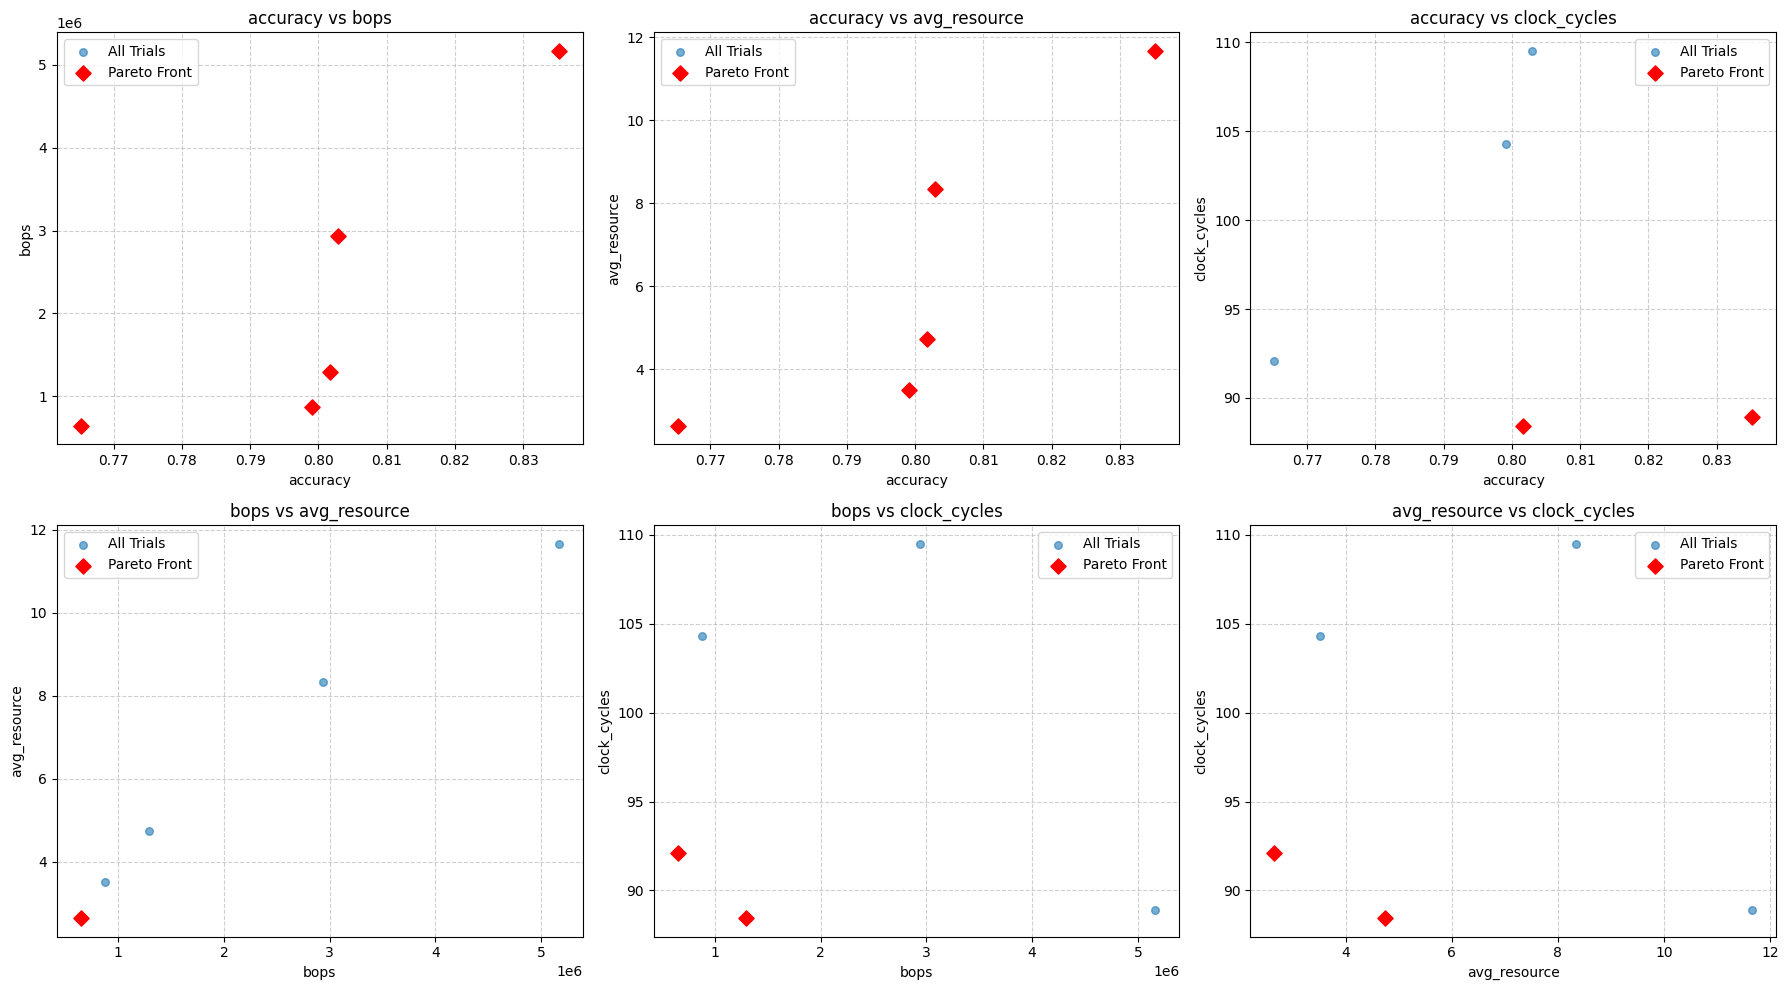


--- Generating 3D Pareto Front Heatmap ---
3D Pareto front plot saved to ./results/tutorial4_MLP/pareto_front_3d.html



MLP search plots saved to: ./results/tutorial4_MLP


In [4]:
# --- Analyze Results for Part 1 ---
print("\n" + "="*50)
print("ANALYZING MLP HARDWARE-AWARE RESULTS")
print("="*50)

results_df_mlp = searcher_mlp.get_results_dataframe()

if not results_df_mlp.empty:
    print("\nMLP Search Summary:")
    print(f"Total trials: {len(results_df_mlp)}")
    print(f"Best Accuracy: {results_df_mlp['accuracy'].max():.4f}")
    
    print("\n--- Visualizing Hardware-Aware Pareto Fronts ---")
    plot_pareto_fronts(results_df_mlp, OBJECTIVE_INFO_HW, save_dir=searcher_mlp.results_dir)
    
    if len(OBJECTIVE_NAMES_HW) >= 4:
        print("\n--- Generating 3D Pareto Front Heatmap ---")
        plot_3d_pareto_front_heatmap(results_df_mlp, OBJECTIVE_INFO_HW, save_dir=searcher_mlp.results_dir)
    
    print(f"\nMLP search plots saved to: {searcher_mlp.results_dir}")
else:
    print("MLP search did not yield any results.")



In [5]:
# ## Part 2: Hybrid Architecture Search
#
# Now we'll use the block-based search to find novel hybrid architectures. Since hardware estimators may not be accurate for these arbitrary structures, we will focus our optimization on two key objectives: **performance (accuracy)** and **computational cost (BOPs)**.

# %%
# --- Configuration for Part 2 ---
N_TRIALS_HYBRID = 15
EPOCHS_HYBRID = 15
SUBSET_SIZE_HYBRID = 20000
RESULTS_DIR_HYBRID = "./results/hybrid_search_tutorial"
SEARCH_SPACE_PATH = 'hybrid_search_space.yaml'

# --- Objectives for Hybrid Search (Performance vs. Cost) ---
OBJECTIVE_NAMES_HYBRID = ['bops', 'performance_metric']
MAXIMIZE_FLAGS_HYBRID = [False, True]
OBJECTIVE_INFO_HYBRID = list(zip(OBJECTIVE_NAMES_HYBRID, MAXIMIZE_FLAGS_HYBRID))

os.makedirs(RESULTS_DIR_HYBRID, exist_ok=True)

# %%
# --- Create the YAML configuration file for the hybrid search ---
search_space_yaml = """
search_spaces:
  channel_space: [8, 16, 32]
  mlp_width_space: [32, 64, 128]
  kernel_space: [1, 3, 5]
  act_space: ["ReLU", "GELU"]
  norm_space: [null, "batch"]
  block_types: ["Conv", "MLP", "None", "ConvAttn"]
  # block_types: ["Conv", "MLP", "None"]
hyperparameters:
  num_blocks: 4
  initial_img_size: 11
  output_dim: 10
"""
with open(SEARCH_SPACE_PATH, 'w') as f:
    f.write(search_space_yaml)
print(f"Created search space configuration file: {SEARCH_SPACE_PATH}")


Created search space configuration file: hybrid_search_space.yaml


In [6]:
# --- Run the Hybrid Search (Simple Method) ---
print("\n" + "="*50)
print("Running Part 2: Hybrid Architecture Search...")
print("="*50)

with open(SEARCH_SPACE_PATH, 'r') as f:
    config = yaml.safe_load(f)
search_space_simple = config.get('search_spaces', {})
search_space_simple.update(config.get('hyperparameters', {}))

searcher_simple = GlobalSearchTF(
    results_dir=RESULTS_DIR_HYBRID + "_simple"
)
searcher_simple.search_space = search_space_simple

study_simple = searcher_simple.run_search(
    model_type='block',
    n_trials=N_TRIALS_HYBRID,
    epochs=EPOCHS_HYBRID,
    dataset='mnist',
    subset_size=SUBSET_SIZE_HYBRID,
    resize_val=searcher_simple.search_space.get('initial_img_size', 11),
    objectives=OBJECTIVE_NAMES_HYBRID,
    maximize_flags=MAXIMIZE_FLAGS_HYBRID,
    verbose=True
)


Running Part 2: Hybrid Architecture Search...

Starting BLOCK Global Search on MNIST



[I 2025-08-29 08:35:25,522] A new study created in memory with name: no-name-0c6ae500-a1d9-4285-aca3-bdf3227a5241


Data loaded and preprocessed:
  Resize: 11x11
  x_train shape: (20000, 11, 11, 1), x_val shape: (10000, 11, 11, 1)
  y_train shape: (20000,), y_val shape: (10000,)


[I 2025-08-29 08:35:32,495] Trial 0 finished with values: [0.7700999975204468, 29458432.0] and parameters: {'b0': 'MLP', 'b1': 'MLP', 'b2': 'None', 'b3': 'None', 'b0_MLP_units': 0, 'b0_MLP_act': 'GELU', 'b0_MLP_norm': 'batch', 'b1_MLP_units': 2, 'b1_MLP_act': 'ReLU', 'b1_MLP_norm': None, 'MLP_Head_width_0': 2, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'GELU', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'ReLU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': 'batch'}.


Trial 0: Accuracy=0.7701, BOPs=29458432


...

Trial 12: Accuracy=0.8062, BOPs=16973824


[I 2025-08-29 08:38:02,940] Trial 13 finished with values: [0.5113999843597412, 193937408.0] and parameters: {'b0': 'Conv', 'b1': 'MLP', 'b2': 'None', 'b3': 'Conv', 'b0_Conv_channels_0': 1, 'b0_Conv_channels_1': 1, 'b0_Conv_kernels_0': 5, 'b0_Conv_kernels_1': 5, 'b0_Conv_acts_0': 'ReLU', 'b0_Conv_acts_1': 'ReLU', 'b0_Conv_norms_0': 'batch', 'b0_Conv_norms_1': None, 'b1_MLP_units': 2, 'b1_MLP_act': 'ReLU', 'b1_MLP_norm': None, 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'GELU', 'MLP_Head_acts_2': 'GELU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': None}.


Trial 13: Accuracy=0.5114, BOPs=193937408


[I 2025-08-29 08:38:19,230] Trial 14 finished with values: [0.3424000144004822, 141328384.0] and parameters: {'b0': 'Conv', 'b1': 'Conv', 'b2': 'ConvAttn', 'b3': 'None', 'b0_Conv_channels_0': 2, 'b0_Conv_channels_1': 2, 'b0_Conv_kernels_0': 5, 'b0_Conv_kernels_1': 3, 'b0_Conv_acts_0': 'ReLU', 'b0_Conv_acts_1': 'ReLU', 'b0_Conv_norms_0': None, 'b0_Conv_norms_1': 'batch', 'b1_Conv_channels_0': 1, 'b1_Conv_channels_1': 1, 'b1_Conv_kernels_0': 5, 'b1_Conv_kernels_1': 1, 'b1_Conv_acts_0': 'ReLU', 'b1_Conv_acts_1': 'ReLU', 'b1_Conv_norms_0': None, 'b1_Conv_norms_1': 'batch', 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 2, 'MLP_Head_acts_0': 'GELU', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'GELU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': 'batch'}.


Trial 14: Accuracy=0.3424, BOPs=141328384

CSV results saved to ./results/hybrid_search_tutorial_simple/block_search_results.csv

🏆 Best model architecture (Trial 10) saved for local search:
   - Source: ./results/hybrid_search_tutorial_simple/trial_10_arch.yaml
   - Destination: ./results/hybrid_search_tutorial_simple/best_model_for_local_search.yaml
   - Accuracy: 0.8610

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 4):
  Values: {'bops': 0.32339999079704285, 'performance_metric': 69804032.0}
  Params: {'b0': 'Conv', 'b1': 'None', 'b2': 'ConvAttn', 'b3': 'Conv', 'b0_Conv_channels_0': 0, 'b0_Conv_channels_1': 2, 'b0_Conv_kernels_0': 3, 'b0_Conv_kernels_1': 5, 'b0_Conv_acts_0': 'GELU', 'b0_Conv_acts_1': 'ReLU', 'b0_Conv_norms_0': 'batch', 'b0_Conv_norms_1': 'batch', 'b3_Conv_channels_0': 0, 'b3_Conv_channels_1': 0, 'b3_Conv_kernels_0': 5, 'b3_Conv_kernels_1': 1, 'b3_Conv_acts_0': 'ReLU', 'b3_Conv_acts_1': 'ReLU', 'b3_Conv_norms_0': 'batch', 'b3_Conv_norms_1': 'batch', 'MLP_Head_width_0':


ANALYZING AND VISUALIZING HYBRID RESULTS
   trial  performance_metric      bops  \
0      0              0.7701  29458432   
1      1              0.6016  93749248   
2      2              0.8554  19955712   
3      3              0.7288  18972672   
4      4              0.3234  69804032   

                                              params  \
0  {'b0': 'MLP', 'b1': 'MLP', 'b2': 'None', 'b3':...   
1  {'b0': 'Conv', 'b1': 'None', 'b2': 'ConvAttn',...   
2  {'b0': 'None', 'b1': 'MLP', 'b2': 'MLP', 'b3':...   
3  {'b0': 'MLP', 'b1': 'None', 'b2': 'MLP', 'b3':...   
4  {'b0': 'Conv', 'b1': 'None', 'b2': 'ConvAttn',...   

                                           yaml_path  
0  ./results/hybrid_search_tutorial_simple/trial_...  
1  ./results/hybrid_search_tutorial_simple/trial_...  
2  ./results/hybrid_search_tutorial_simple/trial_...  
3  ./results/hybrid_search_tutorial_simple/trial_...  
4  ./results/hybrid_search_tutorial_simple/trial_...  

Hybrid Search Results Summary:
Total 

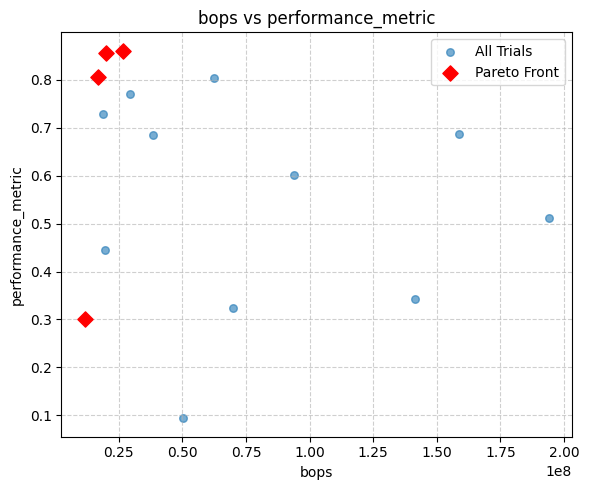


All plots and results saved to: ./results/hybrid_search_tutorial_simple


In [7]:
# ## Analyzing the Hybrid Search Results
#
# For the hybrid search, we analyze the direct trade-off between model performance and its computational cost (BOPs). The Pareto front here will show us which architectures give the best accuracy for a given computational budget.

# %%
print("\n" + "="*50)
print("ANALYZING AND VISUALIZING HYBRID RESULTS")
print("="*50)

results_df_hybrid = pd.DataFrame(searcher_simple.results)
print(results_df_hybrid.head())

if not results_df_hybrid.empty:
    # Display basic statistics
    print("\nHybrid Search Results Summary:")
    print(f"Total trials completed: {len(results_df_hybrid)}")
    print(f"Best Accuracy: {results_df_hybrid['performance_metric'].max():.4f}")
    print(f"Lowest BOPs: {results_df_hybrid['bops'].min()}")

    print("\nTop 5 Hybrid Architectures by Performance:")
    print(results_df_hybrid.sort_values('performance_metric', ascending=False).head())

    # --- Visualize the Pareto Fronts (Accuracy vs BOPs) ---
    print("\n--- Generating Pareto Front Plots for Hybrid Search ---")

    # Generate and display the 2D Pareto front plots
    plot_pareto_fronts(results_df_hybrid, OBJECTIVE_INFO_HYBRID, save_dir=searcher_simple.results_dir)

    print(f"\nAll plots and results saved to: {searcher_simple.results_dir}")
else:
    print("Hybrid search did not yield any results to analyze.")

